In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from MedSAM.MedSAM_Inference import show_mask, show_box

In [2]:
df = pd.read_csv("data/results/dice_medsam.csv")
df.head()

,image_id,dice
0,cju0qkwl35piu0993l0dewei2,0.968581
1,cju0qoxqj9q6s0835b43399p4,0.967970
2,cju0qx73cjw570799j4n5cjze,0.967733
3,cju0roawvklrq0799vmjorwfv,0.961559
4,cju0rx1idathl0835detmsp84,0.950306


In [3]:
# 2. Statistiques descriptives complètes
stats = df['dice'].describe()
print(stats)

count    1000.000000
mean        0.954298
std         0.024184
min         0.629385
25%         0.944214
50%         0.959542
75%         0.969729
max         0.992421
Name: dice, dtype: float64


In [4]:
df.sort_values(by="dice")

,image_id,dice
199,cju2raxlosl630988jdbfy9b0,0.629385
403,cju3uhb79gcgr0871orbrbi3x,0.806905
663,cju76o55nymqd0871h31sph9w,0.841041
326,cju31t8xd17bk0835rnb893jk,0.847432
106,cju1fm3id6gl50801r3fok20c,0.857701
...,...,...
859,cju87vqa0ndwg0850onjdz7ol,0.986053
393,cju3tp94kfstl08181awh6z49,0.986214
976,cju8dqkrqu83i0818ev74qpxq,0.987485
39,cju17otoe119u0799nqcbl8n1,0.988247


In [5]:
img_folder = "data/Kvasir-SEG/images"
output_folder = "data/outputs"
masks_folder = "data/Kvasir-SEG/masks"

with open("data/Kvasir-SEG/kavsir_bboxes.json") as f:
    bboxes = json.load(f)

def show_segmentation(img):
    img_path = os.path.join(img_folder, img)
    img_id = os.path.splitext(img)[0]

    img_np = io.imread(img_path)
    if len(img_np.shape) == 2:
        img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
    else:
        img_3c = img_np

    medsam_seg_path = os.path.join(output_folder, "seg_" + os.path.basename(img_path))
    medsam_seg = io.imread(medsam_seg_path)
    medsam_seg[medsam_seg > 0] = 1

    true_seg_path = os.path.join(masks_folder, img)
    true_seg = io.imread(true_seg_path)[:,:,0]
    true_seg[true_seg > 0] = 1

    _, ax = plt.subplots(1, 3, figsize=(10, 5))

    ax[0].imshow(img_3c)
    ax[1].imshow(img_3c)
    ax[2].imshow(img_3c)

    for bbox in bboxes[img_id]["bbox"]:
        x_min, y_min = bbox["xmin"], bbox["ymin"]
        x_max, y_max = bbox["xmax"], bbox["ymax"]
        box = np.array([x_min, y_min, x_max, y_max])

        show_box(box, ax[0])
        show_box(box, ax[1])

    show_mask(medsam_seg, ax[1])
    show_mask(true_seg, ax[2])

    ax[0].set_title("Input Image and Bounding Box")
    ax[1].set_title("MedSAM Segmentation")
    ax[2].set_title("Ground Truth")

    plt.show()

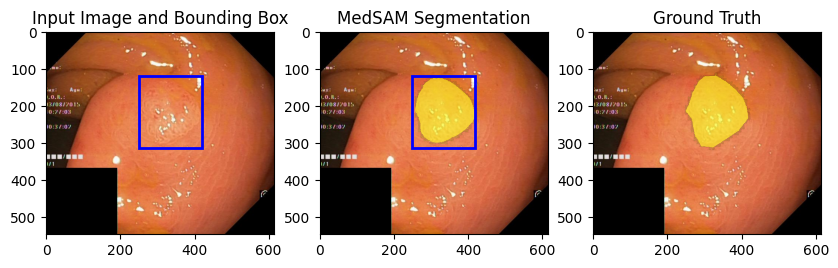

In [6]:
show_segmentation("cju32qr9tbvsj08013pkpjenq.jpg")